# Biomedical Entity Resolution Evaluation & Benchmarking

This notebook implements the reproducible evaluation pipeline for the Biomedical Entity Resolution Assistant. It benchmarks:
1. **Retrieval Search Strategies**: Lexical Search vs Vector Search vs Hybrid Search (RRF).
2. **Embedding Models**: SapBERT vs all-MiniLM-L6-v2 (using in-memory cosine similarity).
3. **End-to-End Pipeline Accuracy**: Named Entity Recognition (NER) + Retrieval + Ranking + Confidence Calibration.
4. **Error Analysis & Tracking**: Roadmapping system failures and calibration calibration curves.

In [3]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np

# Ensure project root is in path
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.evaluation.datasets import load_ground_truth
from src.evaluation.retrieval_eval import evaluate_retrieval_strategies, evaluate_embedding_models
from src.evaluation.entity_eval import evaluate_pipeline
from src.evaluation.visualization import (
    plot_retrieval_comparison,
    plot_accuracy_by_ontology,
    plot_confidence_calibration,
    plot_embedding_model_comparison
)

## 1. Load Ground Truth Dataset

In [4]:
gt_df = load_ground_truth()
print(f"Loaded {len(gt_df)} ground truth cases.")
gt_df.head(10)

Loaded 31 ground truth cases.


,mention,canonical,ontology,identifier
0,a1bg,A1BG,HGNC,HGNC:5
1,a1bg as,A1BG-AS1,HGNC,HGNC:37133
2,acf,A1CF,HGNC,HGNC:24086
3,cpamd5,A2M,HGNC,HGNC:7
4,a2m as1,A2M-AS1,HGNC,HGNC:27057
5,cpamd9,A2ML1,HGNC,HGNC:23336
6,a2ml1 as1,A2ML1-AS1,HGNC,HGNC:41022
7,a2ml1 as2,A2ML1-AS2,HGNC,HGNC:41523
8,a3galt2p,A3GALT2,HGNC,HGNC:30005
9,a14galt,A4GALT,HGNC,HGNC:18149


## 2. Evaluate Retrieval Search Strategies
I evaluate retrieval (top candidates return rates) on Qdrant using:
- Hit Rate@1, Hit Rate@5, Hit Rate@10
- Mean Reciprocal Rank (MRR)

In [5]:
retrieval_results = evaluate_retrieval_strategies(gt_df)
pd.DataFrame(retrieval_results).T

[Qdrant] Connected to server at localhost:6333


,hit_at_1,hit_at_5,hit_at_10,mrr
lexical,1.000000,1.000000,1.000000,1.000000
vector,0.612903,0.645161,0.645161,0.629032
hybrid,1.000000,1.000000,1.000000,1.000000


## 3. Compare Embedding Models
We evaluate in-memory semantic search similarity using:
- `Xenova/SapBERT-from-PubMedBERT-fulltext`
- `Xenova/all-MiniLM-L6-v2`

In [6]:
embedding_models = ["Xenova/SapBERT-from-PubMedBERT-fulltext", "Xenova/all-MiniLM-L6-v2"]
embedding_results = evaluate_embedding_models(gt_df, embedding_models)
pd.DataFrame(embedding_results).T

Evaluating embedding model: Xenova/SapBERT-from-PubMedBERT-fulltext...
Evaluating embedding model: Xenova/all-MiniLM-L6-v2...


,hit_at_1,hit_at_5,hit_at_10,mrr
Xenova/SapBERT-from-PubMedBERT-fulltext,0.870968,0.967742,0.967742,0.913978
Xenova/all-MiniLM-L6-v2,0.838710,0.903226,0.903226,0.870968


## 4. End-to-End Pipeline Evaluation & Calibration
We run the full pipeline to evaluate accuracy, precision, recall, F1-score, and confidence calibration.

In [7]:
pipeline_results = evaluate_pipeline(gt_df)
print("Overall Metrics:", pipeline_results["overall_metrics"])

print("\nAccuracy & F1 by Ontology Slices:")
for ont, metrics in pipeline_results["ontology_metrics"].items():
    print(f"  - {ont}: Accuracy={metrics['accuracy']:.4f}, F1={metrics['f1']:.4f}")

[NER] Warning: Failed to extract with SciSpacy: [E050] Can't find model 'en_core_sci_sm'. It doesn't seem to be a Python package or a valid path to a data directory.
[NER] Loaded 275179 unique aliases for dictionary matching.
[NER] Warning: Failed to extract with SciSpacy: [E050] Can't find model 'en_core_sci_sm'. It doesn't seem to be a Python package or a valid path to a data directory.
[NER] Warning: Failed to extract with SciSpacy: [E050] Can't find model 'en_core_sci_sm'. It doesn't seem to be a Python package or a valid path to a data directory.
[NER] Warning: Failed to extract with SciSpacy: [E050] Can't find model 'en_core_sci_sm'. It doesn't seem to be a Python package or a valid path to a data directory.
[NER] Warning: Failed to extract with SciSpacy: [E050] Can't find model 'en_core_sci_sm'. It doesn't seem to be a Python package or a valid path to a data directory.
[NER] Warning: Failed to extract with SciSpacy: [E050] Can't find model 'en_core_sci_sm'. It doesn't seem to b

## 5. Confidence Calibration Analysis

In [8]:
calib_df = pd.DataFrame(pipeline_results["calibration"]).T
calib_df

,correct,total,accuracy
0.0-0.60,0.0,0.0,0.000000
0.60-0.80,2.0,3.0,0.666667
0.80-0.90,3.0,3.0,1.000000
0.90-1.0,25.0,25.0,1.000000


## 6. Error Analysis
Let's look at the failed entity resolutions to build a roadmap for improvement.

In [9]:
errors_df = pd.DataFrame(pipeline_results["errors"])
if not errors_df.empty:
    display(errors_df)
else:
    print("Perfect resolution run! No errors recorded.")

,Mention,Predicted_ID,Predicted_Canonical,Expected_ID,Expected_Canonical,Confidence,Status,Ontology,Reason
0,1 4 hydroxy 3 methoxyphenyl decan 3 one,HGNC:5461,IGBP1,RXCUI:1928181,1-(4-hydroxy-3-methoxyphenyl)-decan-3-one,0.62,needs_review,RxNorm,Incorrect identifier returned


## 7. Plots and Visualizations
To display the plots generated during the evaluation.

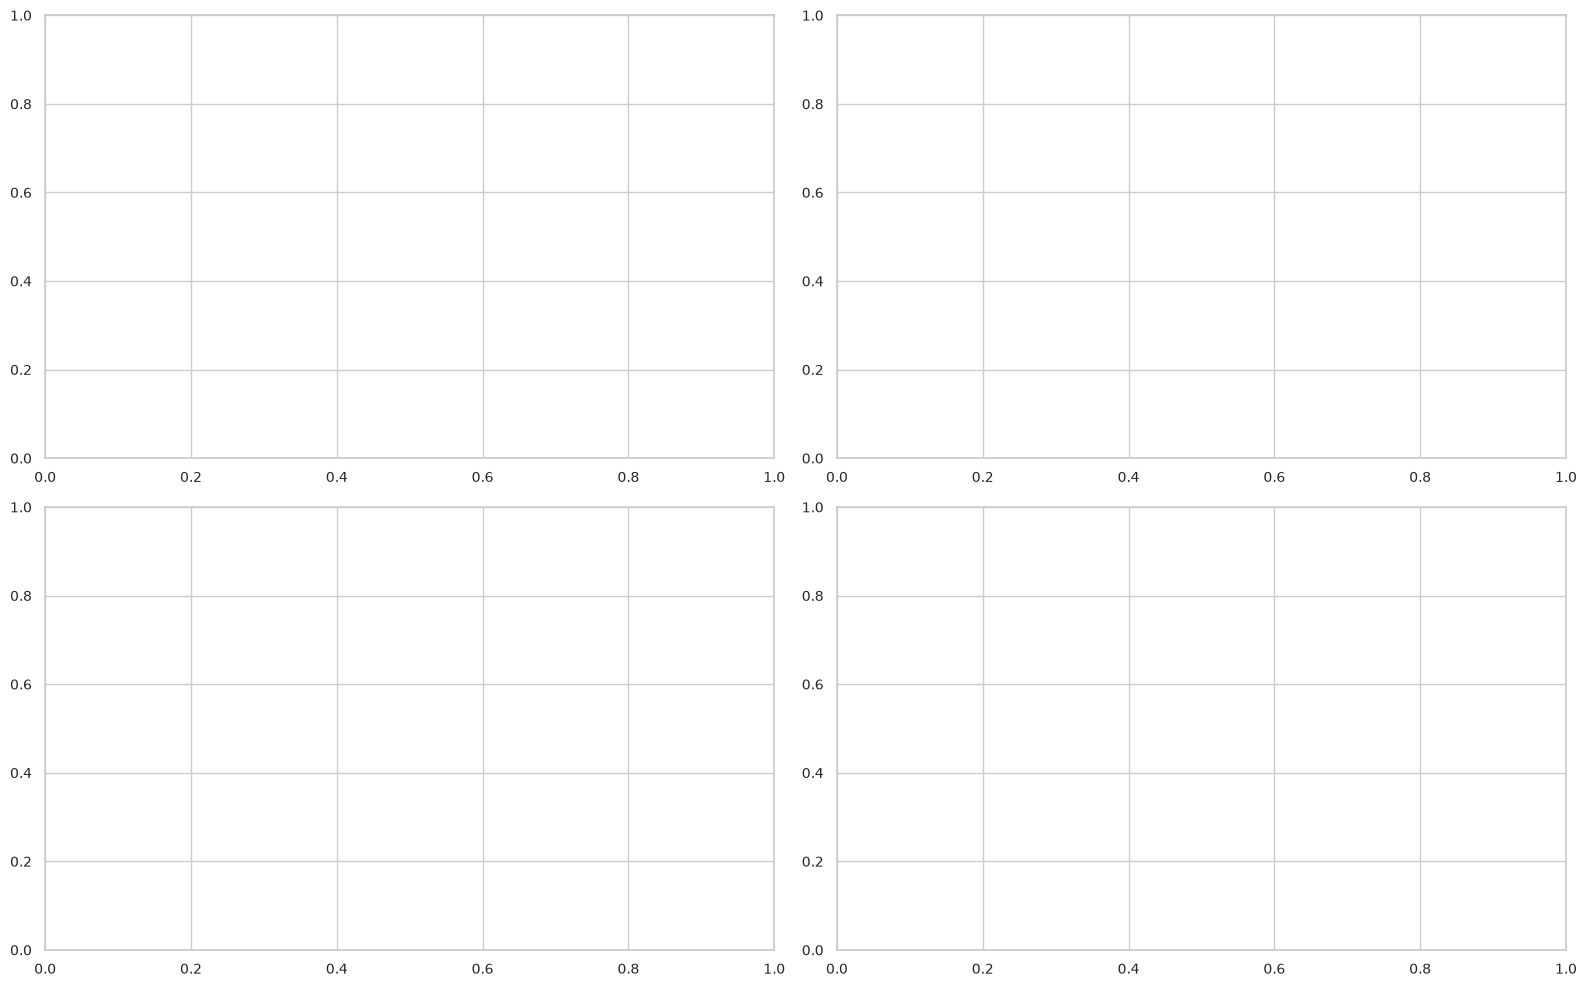

In [10]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

imgs = [
    "retrieval_comparison.png",
    "ontology_performance.png",
    "confidence_calibration.png",
    "embedding_comparison.png"
]

for idx, img_name in enumerate(imgs):
    row, col = idx // 2, idx % 2
    img_path = PROJECT_ROOT / "reports" / "figures" / img_name
    if img_path.exists():
        img = mpimg.imread(str(img_path))
        axes[row, col].imshow(img)
        axes[row, col].axis("off")
        axes[row, col].set_title(img_name.replace(".png", "").replace("_", " ").title())

plt.tight_layout()
plt.show()